<a href="https://colab.research.google.com/github/FadhilTaufiqurrachman/Machine-Learning/blob/main/244107020090_Fadhil_Taufiqurrachman_T4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum Jobsheet 4

NIM : 244107020090

Nama : Fadhil Taufiqurrachman

Kelas : TI 3G

No Absen : 06

Mata Kuliah : Pembelajaran Mesin

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
BASE_PATH = '/content/drive/MyDrive/Education/Current Semester College File /Machine Learning/'

Mounted at /content/drive


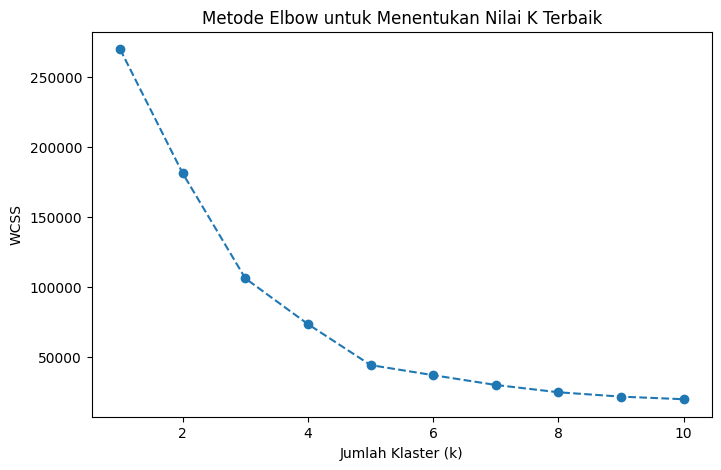

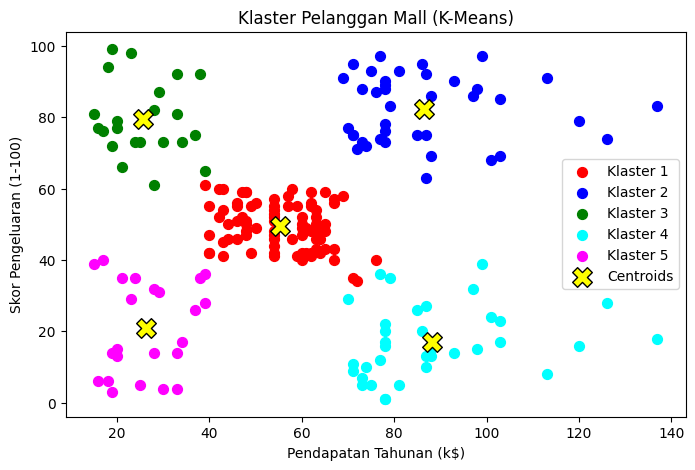

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Gunakan data 'Mall_Customers.csv'
# Ganti path ini jika file berada di folder spesifik Drive Anda
df = pd.read_csv(BASE_PATH + 'Mall_Customers.csv')

# 2. Tentukan fitur yang tepat (Annual Income & Spending Score)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# 3. Mencari jumlah k terbaik dengan Metode Elbow
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Visualisasi Metode Elbow
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Metode Elbow untuk Menentukan Nilai K Terbaik')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('WCSS')
plt.show()

# Dari grafik Elbow, patahan yang paling signifikan ada di k=5.
# Membuat model K-Means dengan k=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# Visualisasi Hasil Klaster K-Means
plt.figure(figsize=(8, 5))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], s=50, c=colors[i], label=f'Klaster {i+1}')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='yellow', label='Centroids', marker='X', edgecolors='black')
plt.title('Klaster Pelanggan Mall (K-Means)')
plt.xlabel('Pendapatan Tahunan (k$)')
plt.ylabel('Skor Pengeluaran (1-100)')
plt.legend()
plt.show()

--- HASIL AWAL ---
Jumlah Klaster: 2
Jumlah Titik Noise: 0

--- EVALUASI METRIK ---
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
ARI: 1.000
AMI: 1.000
Silhouette: 0.391



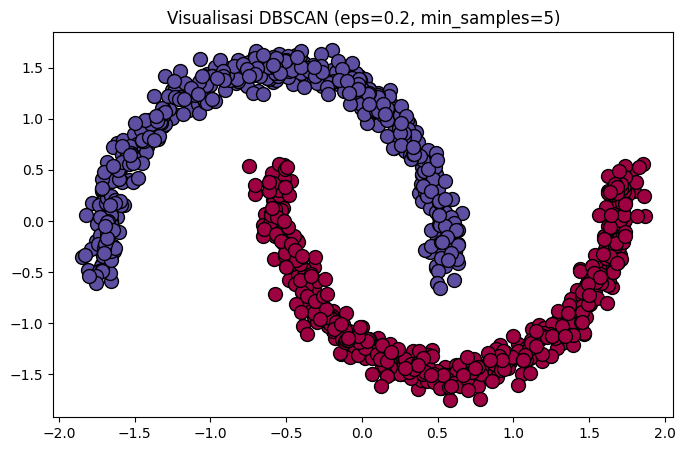

--- EKSPERIMEN ---
eps   | min_samples  | Klaster  | Noise  | Silhouette
-------------------------------------------------------
0.05  | 3            | 69       | 186    | 0.113     
0.05  | 10           | 3        | 970    | -0.294    
0.05  | 20           | 0        | 1000   | N/A       
0.1   | 3            | 2        | 14     | 0.252     
0.1   | 10           | 7        | 57     | 0.162     
0.1   | 20           | 6        | 850    | -0.360    
0.3   | 3            | 2        | 0      | 0.391     
0.3   | 10           | 2        | 0      | 0.391     
0.3   | 20           | 2        | 0      | 0.391     
0.5   | 3            | 2        | 0      | 0.391     
0.5   | 10           | 2        | 0      | 0.391     
0.5   | 20           | 2        | 0      | 0.391     


In [ ]:
import numpy as np
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# 1. Buat dataset make_moons (1000 sampel, noise=0.05), lalu normalisasi
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)
scaler = StandardScaler()
X_moons_scaled = scaler.fit_transform(X_moons)

# 2. Jalankan DBSCAN dengan eps=0.2, min_samples=5
db = DBSCAN(eps=0.2, min_samples=5).fit(X_moons_scaled)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print(f"--- HASIL AWAL ---")
print(f"Jumlah Klaster: {n_clusters_}")
print(f"Jumlah Titik Noise: {n_noise_}\n")

# 3. Evaluasi dengan metrik
print(f"--- EVALUASI METRIK ---")
print(f"Homogeneity: {metrics.homogeneity_score(y_moons, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_moons, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_moons, labels):.3f}")
print(f"ARI: {metrics.adjusted_rand_score(y_moons, labels):.3f}")
print(f"AMI: {metrics.adjusted_mutual_info_score(y_moons, labels):.3f}")
print(f"Silhouette: {metrics.silhouette_score(X_moons_scaled, labels):.3f}\n")

# 4. Visualisasikan hasil DBSCAN
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

plt.figure(figsize=(8,5))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1: # Noise = hitam
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    # Core sample = titik besar
    xy = X_moons_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=10, label='Core' if k==0 else "")

    # Non-core = titik kecil
    xy = X_moons_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col), markeredgecolor='k', markersize=4, label='Non-Core' if k==0 else "")

plt.title(f'Visualisasi DBSCAN (eps=0.2, min_samples=5)')
plt.show()

# 5. Lakukan eksperimen
print(f"--- EKSPERIMEN ---")
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

print(f"{'eps':<5} | {'min_samples':<12} | {'Klaster':<8} | {'Noise':<6} | {'Silhouette':<10}")
print("-" * 55)

for eps in eps_values:
    for ms in min_samples_values:
        db_exp = DBSCAN(eps=eps, min_samples=ms).fit(X_moons_scaled)
        lbls = db_exp.labels_
        c = len(set(lbls)) - (1 if -1 in lbls else 0)
        n = list(lbls).count(-1)

        # Hitung silhouette hanya jika > 1 klaster (jika 0 atau 1 akan error)
        if c > 0 and len(set(lbls)) > 1:
            sil_score = metrics.silhouette_score(X_moons_scaled, lbls)
            sil_str = f"{sil_score:.3f}"
        else:
            sil_str = "N/A"

        print(f"{eps:<5} | {ms:<12} | {c:<8} | {n:<6} | {sil_str:<10}")